# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from glhmm import glhmm, preproc, utils, graphics
import sys 
import pip
import mne
import os

import re
from pathlib import Path

from IPython.display import clear_output

In [65]:
# The following parameters can be adjusting according to the accuracy-speed trade-off
N_STATES = 4
NAP_DURATION_MIN = 20 # Keep the first N minutes of each subject's Nap2 (start taken from the task events)
COVTYPE = 'diag' # 'full' or 'diag'
PREPROC = True # Whether to apply preprocessing (filtering, downsampling, etc.) to the data

# Load and prepare data
Each subject in `Full_EEG/preproc/<subject>/<subject>.fif` is one continuous ~2-3h recording (produced by `helpers/preprocessing.py`), not a set of 10s probes. A session here = one subject's full recording.

Note: at full resolution (500 Hz x 62 channels x 14 subjects, ~2-3h each) concatenating everything would need ~35GB RAM, more than this machine has. Since the recordings are already low-pass filtered at 40Hz (see `preprocessing.py`), we downsample each subject to 100Hz (Nyquist=50Hz, safely above the 40Hz cutoff) right after loading, before concatenating -- this brings the total array down to a manageable size.

In [4]:
data_dir = Path('C:/Users/eva/Documents/Master/ICM/Ilo/EEG')

edf_files = sorted(data_dir.glob('*_filtered.edf'))
print(f"Found {len(edf_files)} files: {[f.name for f in edf_files]}")

# Discard the subjects with nans
edf_files = [f for f in edf_files if not np.isnan(mne.io.read_raw_edf(f, preload=False).get_data()).any()]

Found 16 files: ['TT001_filtered.edf', 'TT002_filtered.edf', 'TT003_filtered.edf', 'TT004_filtered.edf', 'TT005_filtered.edf', 'TT006_filtered.edf', 'TT007_filtered.edf', 'TT008_filtered.edf', 'TT009_filtered.edf', 'TT009_part2_filtered.edf', 'TT010_filtered.edf', 'TT011_filtered.edf', 'TT012_filtered.edf', 'TT012_part2(postnap2)_filtered.edf', 'TT013_a_filtered.edf', 'TT014_a_filtered.edf']
Extracting EDF parameters from C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT001_filtered.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT002_filtered.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT003_filtered.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT004_filtered.edf...
Setting channel info structure

In [9]:
channel_counts = []
for f in edf_files:
    raw_info = mne.io.read_raw_edf(f, preload=False, verbose=False)
    eeg_channels = mne.pick_types(raw_info.info, eeg=True)
    channel_counts.append({
        'subject': f.stem.replace('_filtered', ''),
        'file': f.name,
        'total_channels': len(raw_info.ch_names),
        'eeg_channels': len(eeg_channels),
    })

channel_counts = pd.DataFrame(channel_counts)
print(channel_counts.to_string(index=False))

              subject                               file  total_channels  eeg_channels
                TT001                 TT001_filtered.edf              70            70
                TT002                 TT002_filtered.edf              70            70
                TT003                 TT003_filtered.edf              71            71
                TT004                 TT004_filtered.edf              71            71
                TT005                 TT005_filtered.edf              71            71
                TT006                 TT006_filtered.edf              71            71
                TT007                 TT007_filtered.edf              71            71
                TT008                 TT008_filtered.edf              71            71
                TT009                 TT009_filtered.edf              71            71
          TT009_part2           TT009_part2_filtered.edf              71            71
                TT010                 TT010

In [66]:
TARGET_FS = 100  # Hz: downsampling rate
NON_EEG = ['IO', 'EMG', 'ECG', 'Respi',
           'L_IndexMid', 'L_RingPink', 'L_Thumb', 'R_RingPink', 'R_Thumb',
           'Left Index+Middl', 'Left Ring+Pinky', 'Left Thumb', 'Right Ring+Pinky', 'Right Thumb']

GAMM_DIR = Path('C:/Users/eva/Documents/Master/ICM/Ilo/GAMM')
# Which raw 'Session N' is Nap2 differs between subjects (e.g. TT004 -> Session 7), so take the mapping from the GAMM tables
session_map = pd.read_csv(GAMM_DIR / '09_presses_staged.csv')[['subname', 'session', 'session_raw']].drop_duplicates()
nap2_raw = session_map[session_map.session == 'Nap2'].set_index('subname').session_raw
stages_df = pd.read_csv(GAMM_DIR / '08_sleep_stages.csv')
# onset_s is in seconds from the start of the recording; Nap2 starts at its 'Start Session N' event
nap2_start_s = {sub: stages_df[(stages_df.subname == sub) & (stages_df.session == sess)
                               & stages_df.event.str.startswith('Start')].onset_s.min()
                for sub, sess in nap2_raw.items()}
# Sleep stage per 30-s epoch (epoch_idx = floor(onset_s / 30)). Only epochs containing an event are scored.
EPOCH_S = 30
sleep_stages = {sub: g.dropna(subset=['sleep_stage']).groupby('epoch_idx').sleep_stage.first().to_dict()
                for sub, g in stages_df.groupby('subname')}

Y_list = []
starts, ends = [], []
meta_rows = []
offset = 0

for f in edf_files:
    subject = f.stem.split('_')[0]  # e.g. 'TT013_a_filtered' -> 'TT013'
    print(f"Processing {subject} from file {f.name}...")
    if subject in ['TT003']:
         continue  # skip this subject because it has unusable EEG
    if f.name.__contains__('part2'):
        continue  # skip this file (all Nap2 windows lie in the main recording)
    if np.isnan(nap2_start_s.get(subject, np.nan)):
        print(f"  no Nap2 start found for {subject}, skipping")
        continue

    crop_start_s = nap2_start_s[subject]
    raw = mne.io.read_raw_edf(f, preload=False, verbose=False)
    raw.crop(tmin=crop_start_s, tmax=crop_start_s + NAP_DURATION_MIN * 60, include_tmax=False)
    raw.load_data(verbose=False)
    raw.pick([c for c in raw.ch_names if c not in NON_EEG])  # EDF marks every channel as 'eeg', so drop EMG/ECG/respiration/finger/IO by name
    raw.resample(TARGET_FS, verbose=False)  # anti-alias filtered internally by MNE

    X = raw.get_data().T.astype(np.float32) * 1e6  # (n_times, n_channels), volts -> microvolts
    del raw  # free before loading next subject's data

    Y_list.append(X)
    starts.append(offset)
    ends.append(offset + X.shape[0])
    offset += X.shape[0]

    meta_rows.append({
        'subject': subject,
        'file': str(f),
        'start': starts[-1],
        'end': ends[-1],
        'crop_start_s': crop_start_s,  # absolute time (s from recording start) of the first sample
        'duration_min': round(X.shape[0] / TARGET_FS / 60, 1),
    })
    print(f"  {subject}: {X.shape[0]} samples ({meta_rows[-1]['duration_min']} min)")

assert len({x.shape[1] for x in Y_list}) == 1, 'sessions have different channel counts'
Y = np.vstack(Y_list)
del Y_list
indices = np.column_stack([starts, ends])
sessions_meta = pd.DataFrame(meta_rows)
ch_names = [c for c in mne.io.read_raw_edf(f, preload=False, verbose=False).ch_names if c not in NON_EEG]
fs = TARGET_FS

print(f'\nY shape: {Y.shape}  (n_samples_total x n_channels)')
print(f'indices shape: {indices.shape}  (n_sessions x 2, one per subject)')
print(f'{len(ch_names)} EEG channels, fs = {fs} Hz')
print(f'Y size in memory: {Y.nbytes / 1e9:.2f} GB')
sessions_meta

Processing TT001_filtered from file TT001_filtered.edf...
  TT001_filtered: 60000 samples (10.0 min)
Processing TT002_filtered from file TT002_filtered.edf...
  TT002_filtered: 60000 samples (10.0 min)
Processing TT003_filtered from file TT003_filtered.edf...
  TT003_filtered: 60000 samples (10.0 min)
Processing TT004_filtered from file TT004_filtered.edf...
  TT004_filtered: 60000 samples (10.0 min)
Processing TT005_filtered from file TT005_filtered.edf...
  TT005_filtered: 60000 samples (10.0 min)
Processing TT006_filtered from file TT006_filtered.edf...
  TT006_filtered: 60000 samples (10.0 min)
Processing TT007_filtered from file TT007_filtered.edf...
  TT007_filtered: 60000 samples (10.0 min)
Processing TT008_filtered from file TT008_filtered.edf...
  TT008_filtered: 60000 samples (10.0 min)
Processing TT009_filtered from file TT009_filtered.edf...
  TT009_filtered: 60000 samples (10.0 min)
Processing TT009_part2_filtered from file TT009_part2_filtered.edf...
Processing TT010_filt

,subject,file,start,end,duration_min
0,TT001_filtered,C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT00...,0,60000,10.0
1,TT002_filtered,C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT00...,60000,120000,10.0
2,TT003_filtered,C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT00...,120000,180000,10.0
3,TT004_filtered,C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT00...,180000,240000,10.0
4,TT005_filtered,C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT00...,240000,300000,10.0
5,TT006_filtered,C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT00...,300000,360000,10.0
6,TT007_filtered,C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT00...,360000,420000,10.0
7,TT008_filtered,C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT00...,420000,480000,10.0
8,TT009_filtered,C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT00...,480000,540000,10.0
9,TT010_filtered,C:\Users\eva\Documents\Master\ICM\Ilo\EEG\TT01...,540000,600000,10.0


In [67]:
if PREPROC:
    Y_prep, indices_prep, prep_log = preproc.preprocess_data(data=Y, indices=indices, fs=fs,
        dampen_extreme_peaks=5,
        standardise=True)


    assert not np.isnan(Y_prep).any(), 'NaNs in Y_prep -- dampen_extreme_peaks bug resurfaced'

    print(f'Y_prep shape: {Y_prep.shape}')
    print(f'indices_prep shape: {indices_prep.shape}')
    # Save for reuse in the modelling cells below
    out_dir = Path('C:/Users/eva/Documents/Master/ICM/Nico/GLHMM/outputs')
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / 'Y_prep_full_eeg.npy', Y_prep)
    np.save(out_dir / 'indices_prep_full_eeg.npy', indices_prep)
    sessions_meta.to_csv(out_dir / 'sessions_meta_full_eeg.csv', index=False)
    with open(out_dir / 'channel_names_full_eeg.txt', 'w') as fh:
        fh.write('\n'.join(ch_names))

    print(f'Saved Y_prep_full_eeg.npy, indices_prep_full_eeg.npy, sessions_meta_full_eeg.csv, channel_names_full_eeg.txt to {out_dir}')

Y_prep shape: (840000, 62)
indices_prep shape: (14, 2)
Saved Y_prep_full_eeg.npy, indices_prep_full_eeg.npy, sessions_meta_full_eeg.csv, channel_names_full_eeg.txt to C:\Users\eva\Documents\Master\ICM\Nico\GLHMM\outputs


In [68]:
np.random.seed(42)
hmm = glhmm.glhmm(model_beta='no', K=N_STATES, covtype=COVTYPE)
if not PREPROC:
    Y_prep, indices_prep = Y, indices
Gamma,Xi,FE = hmm.train(X=None, Y=Y_prep, indices=indices_prep)

Init repetition 1 free energy = 55928719.74000151
Init repetition 2 free energy = 55926114.43313556
Init repetition 3 free energy = 55964130.811673015
Init repetition 4 free energy = 56164384.07182669
Init repetition 5 free energy = 55931427.03428516
Best repetition: 2
Cycle 1 free energy = 55921326.61346026
Cycle 2 free energy = 55918056.1892015
Cycle 3, free energy = 55915967.94884974, relative change = 0.3896941688903822
Cycle 4, free energy = 55914568.83750024, relative change = 0.2070372497960743
Cycle 5, free energy = 55913582.766152024, relative change = 0.1273361042597331
Cycle 6, free energy = 55912863.30184528, relative change = 0.08500978570479469
Cycle 7, free energy = 55912343.20729391, relative change = 0.057895027981481224
Cycle 8, free energy = 55911959.764869146, relative change = 0.040936118592818496
Cycle 9, free energy = 55911668.523489326, relative change = 0.030155173610556408
Cycle 10, free energy = 55911443.339841105, relative change = 0.022784317919197914
Cycle

# Inspect model
## State means
Time-varying patterns of amplitude. The state means can be retrieved from the model using `get_means()`functiobn of get_mean(k) to retrieve only the mean for state `k`:

In [69]:
K = hmm.hyperparameters["K"] # the number of states
q = Y_prep.shape[1] # the number of parcels/channels
state_means = np.zeros(shape=(q, K))
state_means = hmm.get_means() # the state means in the shape (no. features, no. states)

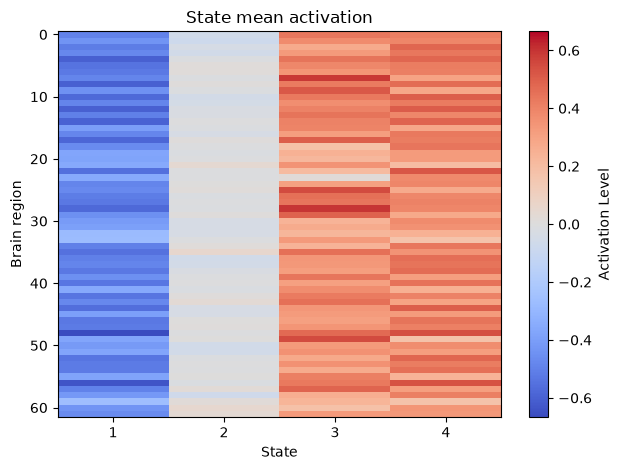

In [70]:
cmap = "coolwarm"
v = np.abs(state_means).max()
plt.imshow(state_means, cmap=cmap, interpolation="none", aspect="auto", vmin=-v, vmax=v)
plt.colorbar(label='Activation Level') # Label for color bar
plt.title("State mean activation")
plt.xticks(np.arange(K), np.arange(1,K+1))
plt.gca().set_xlabel('State')
plt.gca().set_ylabel('Brain region')
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

Plot of the amplitude patterns. It shows the states on the x-axis, each parcel/brain region/channel on the y-axis, and the mean activation of each parcel in each state as the color intensity.



## State dynamic
### Transition probabilities
The transition probabilities indicate the temporal order in the state sequence, i.e., the probability of transitioning from any one state to any other state. They are contained in hmm.P with a shape of [K, K]:

In [71]:
TP = hmm.P.copy() # the transition probability matrix

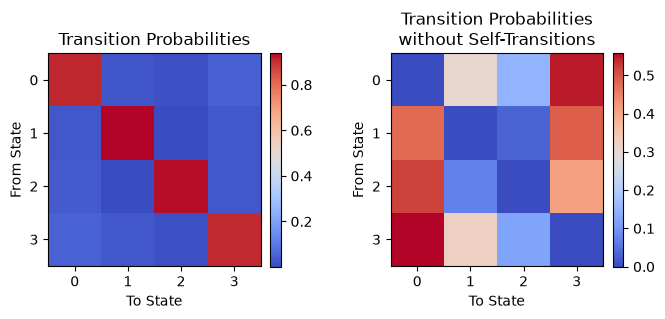

In [72]:
# Plot Transition Probabilities
plt.figure(figsize=(7, 4))

# Plot 1: Original Transition Probabilities
plt.subplot(1, 2, 1)
plt.imshow(TP, cmap=cmap, interpolation='nearest')  # Improved color mapping
plt.title('Transition Probabilities')
plt.xlabel('To State')
plt.ylabel('From State')
plt.colorbar(fraction=0.046, pad=0.04)

# Plot 2: Transition Probabilities without Self-Transitions
TP_noself = TP - np.diag(np.diag(TP))  # Remove self-transitions
TP_noself2 = TP_noself / TP_noself.sum(axis=1, keepdims=True)  # Normalize probabilities
plt.subplot(1, 2, 2)
plt.imshow(TP_noself2, cmap=cmap, interpolation='nearest')  # Improved color mapping
plt.title('Transition Probabilities\nwithout Self-Transitions')
plt.xlabel('To State')
plt.ylabel('From State')
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

### Viterbi path

Discrete representation of the state timecourse, indicating which state is active at which timepoint.

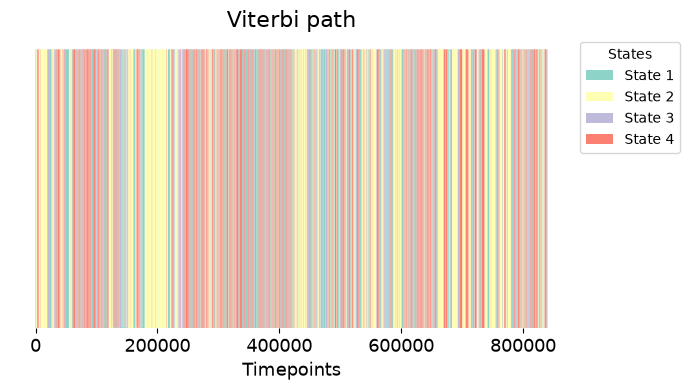

In [73]:
vpath = hmm.decode(X=None, Y=Y_prep, indices=indices_prep, viterbi=True)
graphics.plot_vpath(vpath, title="Viterbi path")

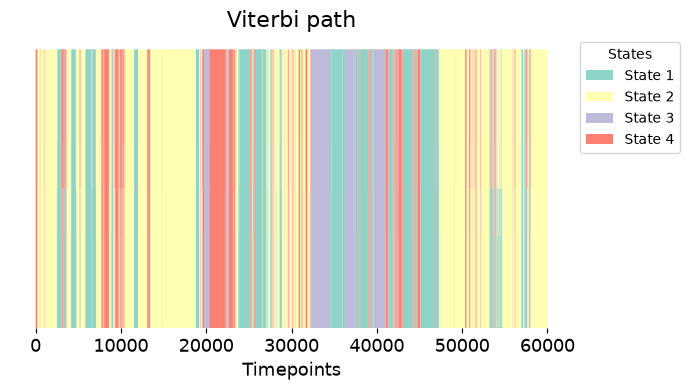

In [74]:
num_subject = 9
graphics.plot_vpath(vpath[indices_prep[num_subject,0]:indices_prep[num_subject,1],:], title=f"Viterbi path")

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


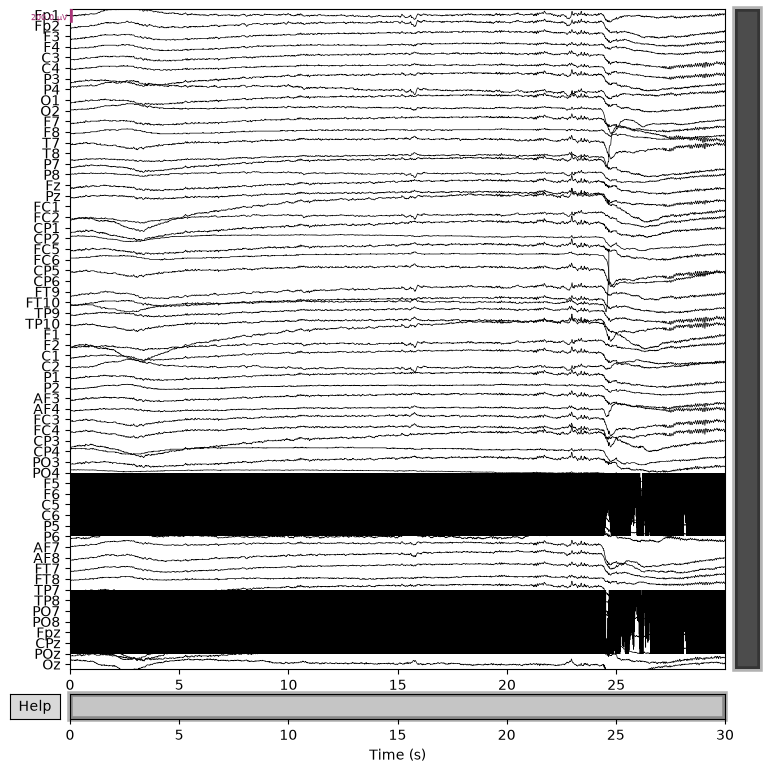

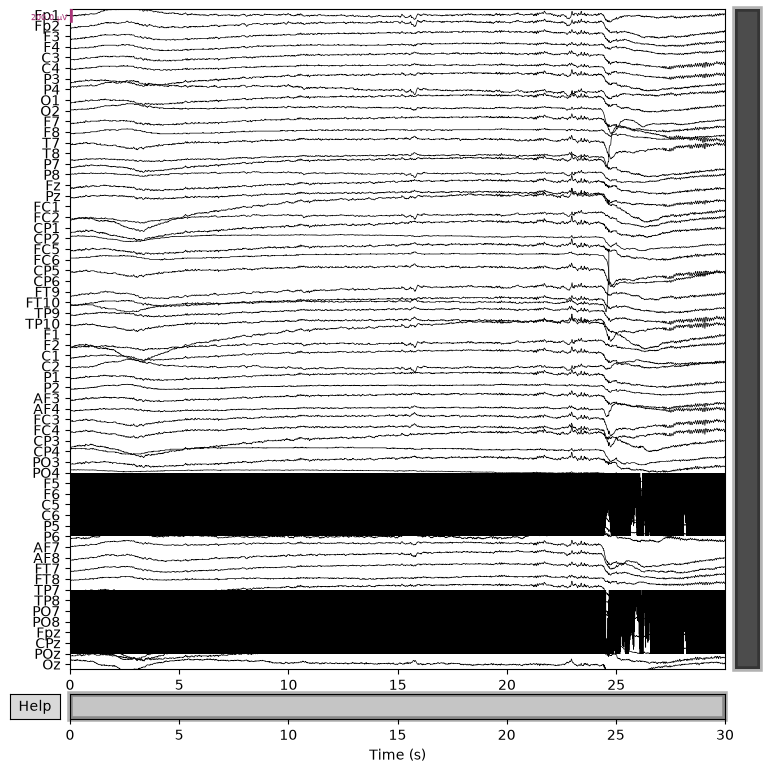

In [96]:
# Plot all TT009 EEG channels with MNE's built-in interactive viewer
SUBJECT = 'TT009'
START_S, DUR_S = 0, 30 # window in seconds from the Nap2 start

s = sessions_meta.index[sessions_meta.subject == SUBJECT][0]
t0, t1 = START_S * fs, (START_S + DUR_S) * fs
eeg = Y[indices[s, 0]:indices[s, 1]][t0:t1]  # microvolts

info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types='eeg')
raw_tt009 = mne.io.RawArray(eeg.T * 1e-6, info, first_samp=int((sessions_meta.crop_start_s[s] + START_S) * fs), verbose=False)  # first_samp keeps absolute recording time  # convert microvolts to volts
raw_tt009.plot(
    n_channels=len(ch_names),
    duration=DUR_S,
    start=0,
    scalings=dict(eeg=100e-6),
    title=f'{SUBJECT}: all EEG channels',
)


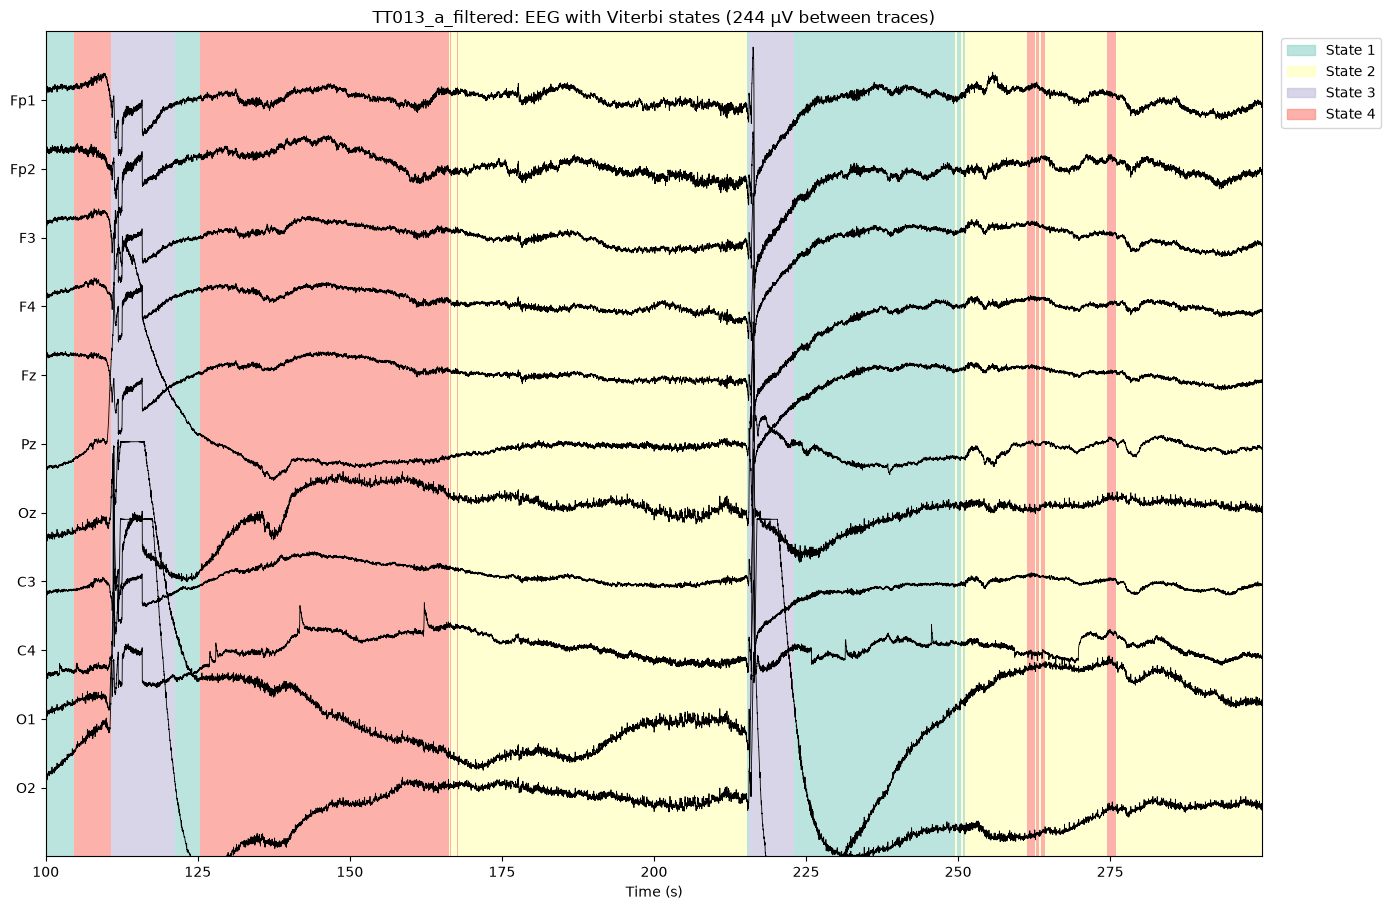

In [103]:
# EEG traces of one session with the Viterbi states as background overlay and the sleep scoring on top
from matplotlib.colors import ListedColormap

SUBJECT = 'TT009'
PLOT_CHANNELS = ['Fz', 'Cz', 'Pz', 'Oz', 'C3', 'C4', 'O1', 'O2']  # missing ones are skipped
START_S, DUR_S = 0, 30  # window to plot, in seconds from the Nap2 start
STAGE_COLORS = {'W': '#f4a261', '1': '#8ecae6', '2': '#219ebc'}

s = sessions_meta.index[sessions_meta.subject == SUBJECT][0]
t0, t1 = START_S * fs, (START_S + DUR_S) * fs
eeg = Y[indices[s, 0]:indices[s, 1]][t0:t1]  # microvolts
states = vpath[indices_prep[s, 0]:indices_prep[s, 1]][t0:t1].argmax(axis=1)
t = sessions_meta.crop_start_s[s] + START_S + np.arange(len(states)) / fs  # absolute time in the recording

chans = [c for c in PLOT_CHANNELS if c in ch_names] or ch_names[:8]
spacing = 4 * np.median([eeg[:, ch_names.index(c)].std() for c in chans])
colors = plt.get_cmap('Set3').colors[:K]

fig, (ax_hyp, ax) = plt.subplots(2, 1, sharex=True, figsize=(14, 0.7 * len(chans) + 2),
                                 gridspec_kw={'height_ratios': [1, 2 * len(chans)], 'hspace': 0.05})

# Sleep scoring: one bar per 30-s epoch, grey where the epoch has no scored event
stages = sleep_stages.get(SUBJECT, {})
for ep in range(int(t[0] // EPOCH_S), int(t[-1] // EPOCH_S) + 1):
    stage = stages.get(ep)
    x0, x1 = max(ep * EPOCH_S, t[0]), min((ep + 1) * EPOCH_S, t[-1])
    ax_hyp.axvspan(x0, x1, color=STAGE_COLORS.get(stage, '0.85'))
    ax_hyp.text((x0 + x1) / 2, 0.5, {'1': 'N1', '2': 'N2'}.get(stage, stage or '?'),
                ha='center', va='center', fontsize=9, clip_on=True)
    ax_hyp.axvline(ep * EPOCH_S, color='k', lw=0.8)
ax_hyp.set_yticks([0.5], ['Sleep stage'])
ax_hyp.set_ylim(0, 1)
ax_hyp.set_title(f'{SUBJECT} Nap2: EEG with Viterbi states ({spacing:.0f} µV between traces)')

ax.imshow(states[None, :], aspect='auto', interpolation='nearest', alpha=0.6,
          cmap=ListedColormap(colors), vmin=-0.5, vmax=K - 0.5,
          extent=[t[0], t[-1], -spacing, spacing * len(chans)])
for i, c in enumerate(chans):
    offset = spacing * (len(chans) - 1 - i)
    x = eeg[:, ch_names.index(c)]
    ax.plot(t, x - x.mean() + offset, color='k', lw=0.6)
ax.set_yticks([spacing * (len(chans) - 1 - i) for i in range(len(chans))], chans)
ax.set_ylim(-spacing, spacing * len(chans))
ax.set_xlim(t[0], t[-1])
ax.set_xlabel('Time from recording start (s)')
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.6) for c in colors],
          labels=[f'State {k + 1}' for k in range(K)], bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()


## Summary metrics
### Fractional occupancy (FO)
The fractional occupancy (FO) indicates the fraction of time in each session that is occupied by each state. For instance, if one state was active for the entire duration of the session, this state's FO would be 1 (100%) and all others would be 0. If, on the other hand, all states are present for an equal amount of timepoints in total, the FO of all states would be 1/K (the number of states). This can be informative to understand whether one state is more present in a certain group of subjects or experimental condition, or to interrogate mixing (explained above).

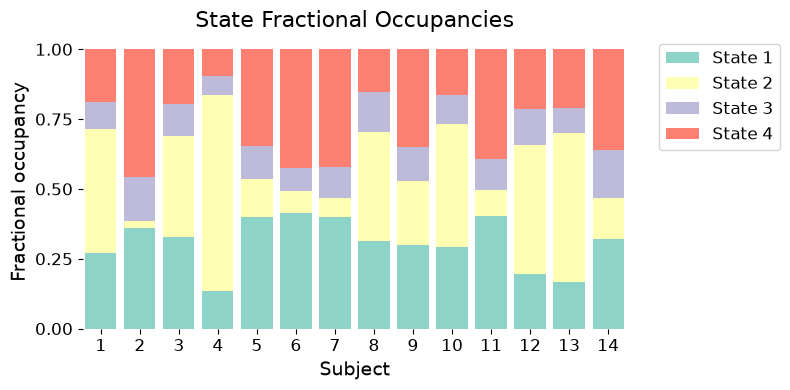

In [75]:
FO = utils.get_FO(Gamma, indices=indices_prep)
graphics.plot_FO(FO, num_x_ticks=FO.shape[0])

### Switching rate
The switching rate indicates how quickly subjects switch between states (as opposed to stay in the same state).

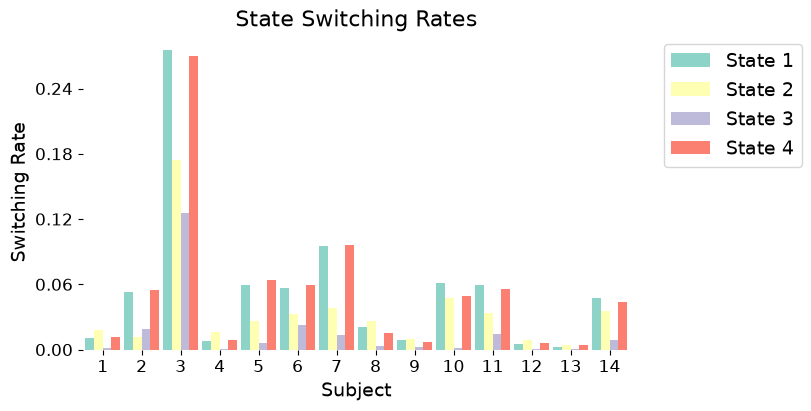

In [76]:
SR = utils.get_switching_rate(Gamma, indices=indices_prep)
graphics.plot_switching_rates(SR, num_x_ticks=SR.shape[0])

### State lifetime
The state lifetimes (also called dwell times) indicate how long a state is active at a time (either on average, median, or maximum). This can be informative to understand whether states tend to last longer or shorter times, pointing towards slower vs. faster dynamics:

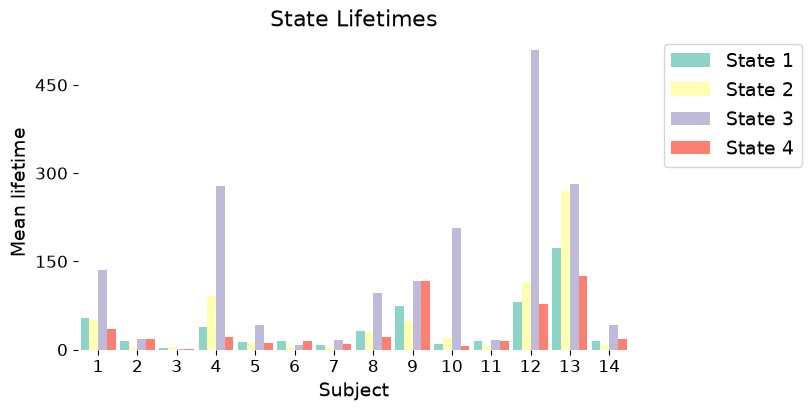

In [77]:
LTmean, LTmed, LTmax = utils.get_life_times(vpath, indices=indices_prep)
graphics.plot_state_lifetimes(LTmean, num_x_ticks=LTmean.shape[0], ylabel='Mean lifetime')

# Not done yet
- Add other channels
- Extend to the whole session